Index(['customer_id', 'name', 'age', 'city', 'income', 'credit_score'], dtype='str')
Index(['customer_id', 'account_number', 'account_type', 'account_balance'], dtype='str')
account_type
Savings    110448798
Salary      41182345
Current     39097745
Name: account_balance, dtype: int64
Index(['transaction_id', 'customer_id', 'transaction_date', 'transaction_type',
       'transaction_amount'],
      dtype='str')
2025-01-01 00:00:00.000000000
In the  February month has highest transaction amount


/var/folders/kv/q2nts_jn1tn6ywsx_v_2vwf80000gn/T/ipykernel_1011/1093188834.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  fig = sns.barplot(data = data3, y= 'Month' , x = 'transaction_amount',palette = 'muted' )


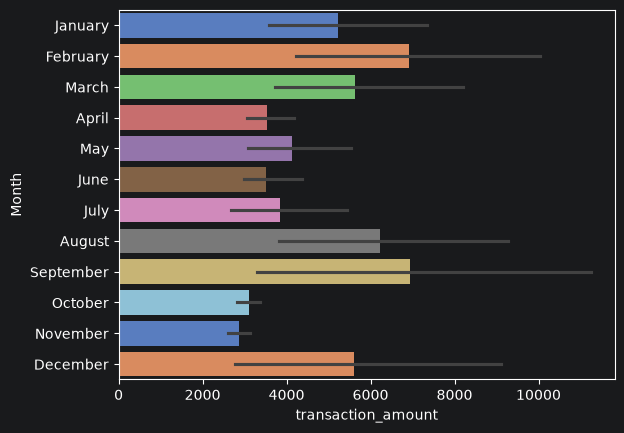

In [54]:
import statistics
from traceback import print_tb

import pandas as pd
import numpy as np
import time
data1 = pd.read_csv("customers.csv")

print(data1.shape)
print(data1.head())
print(data1.columns)
print(data1.info())

Avg_age = np.mean(data1['age'])
Youngest_customers = data1[data1['age'] == data1['age'].min()]
Oldest_customers = data1[data1['age'] == data1['age'].max()]
Ave_income = np.mean(data1['income'])
Highest_income = data1[data1['income'] == data1['income'].max()]
Lowest_income = data1[data1['income'] == data1['income'].min()]

customers_incities = data1['city'].value_counts()

avg_income = data1.groupby('city')['income'].mean()

# problam 5

# print(data1[data1['income'] > 100000]) #the customer whose income is grater 10000o

# print(data1['age'][data1['age'] > 50].count()) # the count the custome whose age is grater then 50

data2 = pd.read_csv("accounts.csv")

Saving_accounts = data2[data2['account_type'] == 'Savings']
# print(Saving_accounts)
Current_account = data2[data2['account_type'] == 'Current']

Salary_account = data2[data2['account_type'] == 'Salary']
print(data2.columns)

Total_balance_in_bank = np.sum(data2['account_balance'])

Avg_account_balance = np.mean(data2['account_balance'])

# print(data2[data2['account_balance'] == data2['account_balance'].max()])

top_10_in_balance = data2['account_balance'].sort_values(ascending=False).head(10) #type 1

top_10_type2 = data2['account_balance'].nlargest(10)

account_type_with_total = data2.groupby(['account_type'])['account_balance'].sum().sort_values(ascending=False)
print(account_type_with_total)


# Merge Data

data1_2 = data1.merge(
    data2,
    on = 'customer_id'
)

avg_balance_in_each_city = data1_2.groupby('city')['account_balance'].mean()

correlation = data1_2['income'].corr(data1_2['account_balance'])
'''
+1  → Strong positive relationship
 0  → Little/no linear relationship
-1  → Strong negative relationship
'''

hight_income = data1_2[data1_2['income'] == data1_2['income'].max()]

data3 = pd.read_csv('transactions.csv')
print(data3.columns)

Total_transaction = len(data3)

avg_transaction_amount = np.sum(data3['transaction_amount'])

max_transaction_amount = data3[data3['transaction_amount'] == data3['transaction_amount'].max()]

min_transaction_amount = data3[data3['transaction_amount'] == data3['transaction_amount'].min()]

# print(data3['transaction_type'].value_counts()) # its tell us how many transaction here present

divaide_transection = data3.groupby('transaction_type')['transaction_amount'].sum()

top_10_in_transaction = data3.nlargest(10,'transaction_amount')

print(data3['transaction_date'].iloc[0])
month = []
year = []
day = []
for i in range(Total_transaction):
    transaction_data = data3['transaction_date'].iloc[i].split(' ')
    date_data = transaction_data[0]
    result = time.strptime(date_data, '%Y-%m-%d')
    month_name = time.strftime("%B",result)
    month.append(month_name)
    year_name = time.strftime("%Y",result)
    year.append(year_name)
    day_name = time.strftime("%A",result)
    day.append(day_name)

data3['Month'] = month
data3['Year'] = year
data3['Day'] = day


Monthly_transaction_count = data3.groupby('Month')['transaction_id'].count().sort_values(ascending=False)

Monthly_transaction_amount = data3.groupby(['Month'])['transaction_amount'].sum().sort_values(ascending=False)

print(f"In the  {Monthly_transaction_amount.index[0]} month has highest transaction amount")
import matplotlib.pyplot as plt
import seaborn as sns

fig = sns.barplot(data = data3, y= 'Month' , x = 'transaction_amount',palette = 'muted' )

plt.show()



In [55]:
# Use stats
from scipy import stats
import statistics as st

stat_mean = st.mean(data3['transaction_amount'])
stat_Median = st.median(data3['transaction_amount'])
stst_Mode = st.mode(data3['transaction_amount'])
stat_Variance = st.variance(data3['transaction_amount'])
stat_25_percentile = np.percentile(data3['transaction_amount'],q = 25)
stat_50_percentile = np.percentile(data3['transaction_amount'],q = 50)

stat_75_percentile = np.percentile(data3['transaction_amount'],q = 75)

In [42]:
stat_std = st.stdev(data3['transaction_amount'])
print(stat_std)
print(stat_mean)
# If the diff between std & mean that's why

33537.74583715897
4812.5945833333335


In [53]:
# Find unusual transaction
cut_off = stat_mean + (stat_std)*3

Unusual_transaction = data3[data3['transaction_amount'] > cut_off]


In [17]:
Unusual_transaction

,transaction_id,customer_id,transaction_date,transaction_type,transaction_amount,Month,Year,Day
740,T000741,C2483,2025-02-07 10:26:05.530460871,Withdrawal,415682,February,2025,Friday
755,T000756,C0321,2025-02-08 04:38:46.993916159,Withdrawal,631038,February,2025,Saturday
767,T000768,C0023,2025-02-08 19:12:56.164680390,Deposit,637614,February,2025,Saturday
875,T000876,C2035,2025-02-14 06:20:18.701558463,Withdrawal,873077,February,2025,Friday
952,T000953,C2135,2025-02-18 03:49:27.547295608,Withdrawal,635847,February,2025,Tuesday
1229,T001230,C1457,2025-03-04 04:07:49.239103259,Withdrawal,510043,March,2025,Tuesday
1369,T001370,C0233,2025-03-11 06:06:16.231352613,Withdrawal,581431,March,2025,Tuesday
1724,T001725,C1876,2025-03-29 05:06:37.533127761,Deposit,627610,March,2025,Saturday
3273,T003274,C1853,2025-06-15 13:45:11.325943828,Deposit,389840,June,2025,Sunday
3523,T003524,C0636,2025-06-28 05:16:42.383531960,Deposit,108262,June,2025,Saturday


In [67]:
data3_suspicious = Unusual_transaction
# print(data1)
# print(data2)
# print(data3)
data12 = data1.merge(data2, on='customer_id')
data123 = data12.merge(data3, on='customer_id')
print(data123.columns)

Index(['customer_id', 'name', 'age', 'city', 'income', 'credit_score',
       'account_number', 'account_type', 'account_balance', 'transaction_id',
       'transaction_date', 'transaction_type', 'transaction_amount', 'Month',
       'Year', 'Day'],
      dtype='str')


In [72]:
data_mean = statistics.mean(data123['account_balance'])
data_std = statistics.stdev(data123['account_balance'])

thresold = data_mean + (data_std)*3

suspicious_data = data123[data123['account_balance'] > thresold][['transaction_id','customer_id','transaction_amount','transaction_date','city','account_type','credit_score','account_balance']]
print(pd.DataFrame(suspicious_data).columns)
max_suspious = suspicious_data[suspicious_data['account_balance'] == suspicious_data['account_balance'].max()]
print(max_suspious)

Index(['transaction_id', 'customer_id', 'transaction_amount',
       'transaction_date', 'city', 'account_type', 'credit_score',
       'account_balance'],
      dtype='str')
     transaction_id customer_id  transaction_amount  \
7963        T000052       C1670               16077   
7964        T005036       C1670                7308   
7965        T009077       C1670               24737   
7966        T009893       C1670                3666   
7967        T011793       C1670               13100   

                   transaction_date   city account_type  credit_score  \
7963  2025-01-03 13:55:08.975747979  Delhi      Savings           634   
7964  2025-09-12 16:59:57.899824984  Delhi      Savings           634   
7965  2026-04-05 03:10:56.154679552  Delhi      Savings           634   
7966  2026-05-16 09:53:19.766647216  Delhi      Savings           634   
7967  2026-08-20 12:40:51.804317024  Delhi      Savings           634   

      account_balance  
7963           886241  
7964   

In [78]:
groupby_city_transaction_data = suspicious_data.groupby('city')['transaction_amount'].sum().sort_values(ascending = False)
print(groupby_city_transaction_data)
print(f"{groupby_city_transaction_data.index[0]} has highest transaction amount {groupby_city_transaction_data.values[0]}")

city
Vadodara     527597
Surat        291065
Delhi        286214
Rajkot       232080
Bengaluru    218327
Ahmedabad    196416
Pune         177827
Mumbai       140447
Name: transaction_amount, dtype: int64
Vadodara has highest transaction amount 527597


In [80]:
suspicious_data_type_count = suspicious_data['account_type'].value_counts()
print(suspicious_data_type_count)

account_type
Savings    109
Salary      62
Current     51
Name: count, dtype: int64


In [81]:
# Loan Analysis

In [82]:
loan_data = pd.read_csv('loans.csv')
print(loan_data)

     customer_id  loan_amount loan_status
0          C0001            0     No Loan
1          C0002       563001    Rejected
2          C0003            0     No Loan
3          C0004       109991    Approved
4          C0005            0     No Loan
...          ...          ...         ...
2495       C2496            0     No Loan
2496       C2497            0     No Loan
2497       C2498            0     No Loan
2498       C2499            0     No Loan
2499       C2500       136278    Approved

[2500 rows x 3 columns]


In [83]:
loan_status_count = loan_data['loan_status'].value_counts()
print(loan_status_count)

loan_status
No Loan     1534
Approved     717
Rejected     249
Name: count, dtype: int64


In [84]:
avg_loan_amount = statistics.mean(loan_data['loan_amount'])
print(avg_loan_amount)

70882.338


In [93]:
data123Loan = data123.merge(loan_data, on='customer_id')

print(data123Loan.iloc[9])

customer_id                                   C0002
name                                  Customer_0002
age                                              64
city                                      Bengaluru
income                                       125350
credit_score                                    544
account_number                             AC100001
account_type                                Savings
account_balance                              121579
transaction_id                              T004475
transaction_date      2025-08-15 07:53:19.166597216
transaction_type                            Deposit
transaction_amount                             4595
Month                                        August
Year                                           2025
Day                                          Friday
loan_amount                                  563001
loan_status                                Rejected
Name: 9, dtype: object


In [111]:
apprual_data = data123Loan[data123Loan['loan_status'] == 'Approved']['credit_score'].dropna()
rejected_data = data123Loan[data123Loan['loan_status'] == 'Rejected']['credit_score'].dropna()

print("Approved average :",np.mean(apprual_data))
print("Rejected average :",np.mean(rejected_data))

Approved average : 700.3765359859567
Rejected average : 645.8759183673469


| Correlation | Meaning                        |
| ----------: | ------------------------------ |
|        `+1` | Perfect positive relationship  |
|      `+0.8` | Strong positive relationship   |
|      `+0.5` | Moderate positive relationship |
|         `0` | No linear relationship         |
|      `-0.5` | Moderate negative relationship |
|      `-0.8` | Strong negative relationship   |
|        `-1` | Perfect negative relationship  |


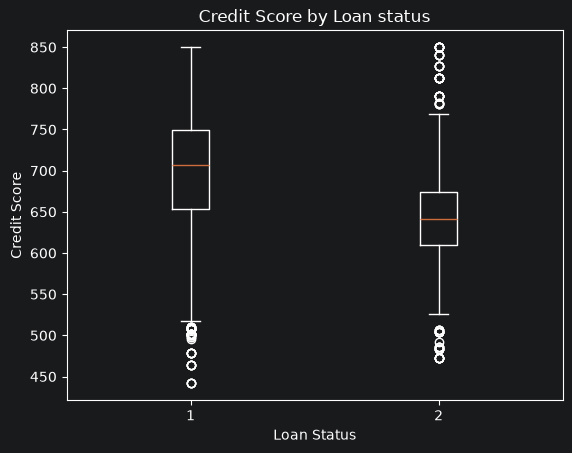

In [119]:
import matplotlib.pyplot as plt

plt.boxplot(
    [apprual_data, rejected_data],

    # labels = ['Approved','Rejected']

)

plt.ylabel('Credit Score')
plt.xlabel('Loan Status')
plt.title('Credit Score by Loan status')
plt.show()

T - TEST


In [124]:

from scipy.stats import ttest_ind

stat , p_value = ttest_ind(
    apprual_data,
    rejected_data,
    equal_var = False,
)
print("p_value :",p_value)
if p_value < 0.05:
    print("I reject my null hypothesis and there are some group")

else:
    print("I accept my null hypothesis and there sre no significantly deffer")

p_value : 1.0529794677917603e-120
I reject my null hypothesis and there are some group


In [130]:
credit_poor = data123Loan[(300 <= data123Loan['credit_score'] ) & (data123Loan['credit_score'] <= 549) ].sort_values(by = 'credit_score', ascending = False)

credit_fair = data123Loan[(550 <= data123Loan['credit_score'] ) & (data123Loan['credit_score'] <= 649) ].sort_values(by = 'credit_score', ascending = False)

credit_Good = data123Loan[(650 <= data123Loan['credit_score'] ) & (data123Loan['credit_score'] <= 749) ].sort_values(by = 'credit_score', ascending = False)

credit_Excellent = data123Loan[(750 <= data123Loan['credit_score'] ) & (data123Loan['credit_score'] <= 850) ].sort_values(by = 'credit_score', ascending = False)

In [134]:
approval_rate_poor = ((credit_poor['loan_status'][credit_poor['loan_status'] == 'Approved'].count())/len(credit_poor))*100

approval_rate_fair = ((credit_fair['loan_status'][credit_fair['loan_status'] == 'Approved'].count())/len(credit_fair))*100

approval_rate_Good = ((credit_Good['loan_status'][credit_Good['loan_status'] == 'Approved'].count())/len(credit_Good))*100

approval_rate_Excellent = ((credit_Excellent['loan_status'][credit_Excellent['loan_status'] == 'Approved'].count())/len(credit_Excellent))*100


In [147]:

# Final Business Analysis
print(data123Loan.nlargest(10,['account_balance','credit_score']))

     customer_id           name  age   city  income  credit_score  \
7963       C1670  Customer_1670   55  Delhi  510931           634   
7964       C1670  Customer_1670   55  Delhi  510931           634   
7965       C1670  Customer_1670   55  Delhi  510931           634   
7966       C1670  Customer_1670   55  Delhi  510931           634   
7967       C1670  Customer_1670   55  Delhi  510931           634   
7147       C1500  Customer_1500   52  Delhi  324311           841   
7148       C1500  Customer_1500   52  Delhi  324311           841   
7149       C1500  Customer_1500   52  Delhi  324311           841   
7150       C1500  Customer_1500   52  Delhi  324311           841   
7151       C1500  Customer_1500   52  Delhi  324311           841   

     account_number account_type  account_balance transaction_id  \
7963       AC101669      Savings           886241        T000052   
7964       AC101669      Savings           886241        T005036   
7965       AC101669      Savings    

income
account balance
transaction activity
credit score


In [149]:
print(data123Loan[(data123Loan['income'] == data123Loan['income'].max()) & data123Loan['account_balance'] == data123Loan['account_balance'].max()])

Empty DataFrame
Columns: [customer_id, name, age, city, income, credit_score, account_number, account_type, account_balance, transaction_id, transaction_date, transaction_type, transaction_amount, Month, Year, Day, loan_amount, loan_status]
Index: []


Base on Income

In [174]:
use_base_data = data123Loan[['income','account_balance','transaction_type','transaction_amount','credit_score','name','age']]


In [175]:
print(use_base_data.nlargest(10,'income').sort_values(by = 'income', ascending = False))

      income  account_balance transaction_type  transaction_amount  \
7963  510931           886241       Withdrawal               16077   
7964  510931           886241       Withdrawal                7308   
7965  510931           886241          Deposit               24737   
7966  510931           886241         Transfer                3666   
7967  510931           886241       Withdrawal               13100   
7147  324311           676487       Withdrawal                5011   
7148  324311           676487         Transfer               21281   
7149  324311           676487          Deposit               11414   
7150  324311           676487          Deposit               14737   
7151  324311           676487       Withdrawal               18881   

      credit_score           name  age  
7963           634  Customer_1670   55  
7964           634  Customer_1670   55  
7965           634  Customer_1670   55  
7966           634  Customer_1670   55  
7967           634  Cust

In [182]:
base_income = use_base_data.nlargest(10,'income').sort_values(by = 'account_balance', ascending = False).head(5)
name_base_income = base_income['name']

In [190]:
base_account_balance = use_base_data.nlargest(10,'account_balance').sort_values(by = 'account_balance', ascending = False).head(5)
name_base_balance = base_income['name']

In [233]:
base_transaction_activity = data123Loan.groupby(['customer_id'])['transaction_id'].count()
most_time = base_transaction_activity
times = pd.DataFrame(most_time)
data12_ranks = data12.merge(times, on = 'customer_id', how = 'outer')
# data123Loan['transaction_count'] = most_time.values
print(data12_renks.columns)

Index(['customer_id', 'name', 'age', 'city', 'income', 'credit_score',
       'account_number', 'account_type', 'account_balance', 'transaction_id'],
      dtype='str')


In [235]:
data12_ranks["income_rank"] = data12_ranks["income"].rank(pct=True)

data12_ranks["balance_rank"] = data12_ranks["account_balance"].rank(pct=True)

data12_ranks["transaction_rank"] = data12_ranks["transaction_id"].rank(pct=True)

In [238]:
print(data12_ranks['income_rank'])

0       0.3564
1       0.9328
2       0.9808
3       0.1700
4       0.5076
         ...  
2495    0.5232
2496    0.7216
2497    0.3336
2498    0.9856
2499    0.9316
Name: income_rank, Length: 2500, dtype: float64


In [239]:
data12_ranks["value_score"] = (
    data12_ranks["income_rank"] +
    data12_ranks["balance_rank"] +
    data12_ranks["transaction_rank"]
)

In [250]:
top_customers = data12_ranks.nlargest(10,"value_score").sort_values(by = 'value_score', ascending = False)
print(top_customers)

     customer_id           name  age       city  income  credit_score  \
1757       C1758  Customer_1758   30   Vadodara  262829           677   
2236       C2237  Customer_2237   41  Bengaluru  176601           641   
2057       C2058  Customer_2058   69      Surat  224547           577   
2390       C2391  Customer_2391   63      Surat  134753           611   
2140       C2141  Customer_2141   33      Delhi  186897           655   
2250       C2251  Customer_2251   33     Rajkot  113292           672   
2330       C2331  Customer_2331   45  Ahmedabad  121832           665   
2198       C2199  Customer_2199   37     Mumbai  132086           590   
2427       C2428  Customer_2428   59  Bengaluru  175322           729   
2020       C2021  Customer_2021   66  Bengaluru  171393           730   

     account_number account_type  account_balance  transaction_id  \
1757       AC101757       Salary           405439            11.0   
2236       AC102236      Savings           386140         

In [259]:
print(top_customers[['customer_id','name','age','city','income','account_balance','transaction_rank','value_score']])

     customer_id           name  age       city  income  account_balance  \
1757       C1758  Customer_1758   30   Vadodara  262829           405439   
2236       C2237  Customer_2237   41  Bengaluru  176601           386140   
2057       C2058  Customer_2058   69      Surat  224547           298956   
2390       C2391  Customer_2391   63      Surat  134753           287299   
2140       C2141  Customer_2141   33      Delhi  186897           312626   
2250       C2251  Customer_2251   33     Rajkot  113292           231034   
2330       C2331  Customer_2331   45  Ahmedabad  121832           214330   
2198       C2199  Customer_2199   37     Mumbai  132086           176909   
2427       C2428  Customer_2428   59  Bengaluru  175322           167368   
2020       C2021  Customer_2021   66  Bengaluru  171393           199273   

      transaction_rank  value_score  
1757          0.992342     2.986342  
2236          0.992342     2.969542  
2057          0.955260     2.939660  
2390       